# Favorita Grocery Sales Forecasting


## 1. Постановка задачи

Нужно предсказать продажи `unit_sales` для каждой тройки

- `date`
- `store_nbr`
- `item_nbr`

на горизонте **16 дней** (датасет `test.csv`).

Это задача **panel time series forecasting**: у нас много временных рядов одновременно, по одному на каждую пару `(store_nbr, item_nbr)`.

### Особенности задачи

- много рядов с нулями;
- сильная недельная сезонность;
- влияние промоакций;
- влияние календаря/праздников;
- есть внешние признаки: `oil`, `transactions`, `stores`, `items`, `holidays_events`;
- целевая метрика соревнования — **NWRMSLE**, то есть взвешенный логарифмический RMSLE, где для perishable-товаров вес выше.

## 2. Протокол валидации

Случайный train/valid split здесь использовать нельзя: он ломает временную структуру.

Используем **chronological holdout**, который максимально похож на Kaggle:

- **train history**: всё прошлое до `2017-07-31`
- **validation horizon**: `2017-08-01` … `2017-08-15`
- **test horizon**: `2017-08-16` … `2017-08-31`

Почему это хороший протокол:
- горизонт валидации и теста одинаковый: **16 дней**;
- модель обучается на прошлом и проверяется на будущем;
- можно честно измерять, помогают ли новые признаки/модели.

Для классических time-series baseline и DL-модели этого достаточно.  
Для ML-модели дополнительно можно сделать rolling backtest, но в рамках домашнего задания один holdout на последних 16 днях — уже корректное и понятное решение.

In [1]:
import os
import gc
import math
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

def reduce_mem_usage(df, category_threshold=0.5):
    """Downcast числовые типы и переводит часть object в category."""
    start_mem = df.memory_usage(deep=True).sum() / 1024**2

    for col in df.columns:
        col_type = df[col].dtype

        if pd.api.types.is_datetime64_any_dtype(col_type) or pd.api.types.is_categorical_dtype(col_type):
            continue

        if pd.api.types.is_bool_dtype(col_type):
            df[col] = df[col].astype("int8")
            continue

        if pd.api.types.is_integer_dtype(col_type):
            df[col] = pd.to_numeric(df[col], downcast="integer")
            continue

        if pd.api.types.is_float_dtype(col_type):
            df[col] = pd.to_numeric(df[col], downcast="float")
            continue

        if col_type == object:
            nunique = df[col].nunique(dropna=False)
            if len(df) > 0 and nunique / len(df) <= category_threshold:
                df[col] = df[col].astype("category")

    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory usage: {start_mem:.2f} MB -> {end_mem:.2f} MB")
    return df

def mem_mb(df):
    return df.memory_usage(deep=True).sum() / 1024**2

In [2]:
DATA_DIR = "data/favorita-grocery-sales-forecasting"

TRAIN_USECOLS = ["date", "store_nbr", "item_nbr", "unit_sales", "onpromotion"]
TEST_USECOLS = ["id", "date", "store_nbr", "item_nbr", "onpromotion"]

train_dtypes = {
    "store_nbr": "int16",
    "item_nbr": "int32",
    "unit_sales": "float32",
    "onpromotion": "bool",
}

test_dtypes = {
    "id": "int64",
    "store_nbr": "int16",
    "item_nbr": "int32",
    "onpromotion": "bool",
}

stores_dtypes = {
    "store_nbr": "int16",
    "city": "category",
    "state": "category",
    "type": "category",
    "cluster": "int16",
}

items_dtypes = {
    "item_nbr": "int32",
    "family": "category",
    "class": "int16",
    "perishable": "int8",
}

transactions_dtypes = {
    "store_nbr": "int16",
    "transactions": "float32",
}

In [3]:
def normalize_onpromotion(s):
    return (
        s.fillna(False)
         .replace({
             True: 1, False: 0,
             "True": 1, "False": 0,
             "true": 1, "false": 0,
             1: 1, 0: 0,
             "1": 1, "0": 0,
         })
         .astype("int8")
    )

test = pd.read_csv(
    f"{DATA_DIR}/test.csv",
    usecols=TEST_USECOLS,
    parse_dates=["date"],
    dtype={
        **{k: v for k, v in test_dtypes.items() if k != "onpromotion"},
        "onpromotion": "object",
    },
)

test["onpromotion"] = normalize_onpromotion(test["onpromotion"])

test_start_date = test["date"].min()
HISTORY_DAYS = 120
train_cutoff = test_start_date - pd.Timedelta(days=HISTORY_DAYS)

train_chunks = []
for chunk in pd.read_csv(
    f"{DATA_DIR}/train.csv",
    usecols=TRAIN_USECOLS,
    parse_dates=["date"],
    chunksize=2_000_000,
    dtype={
        **{k: v for k, v in train_dtypes.items() if k != "onpromotion"},
        "onpromotion": "object",
    },
):
    chunk = chunk[chunk["date"] >= train_cutoff]
    if not chunk.empty:
        chunk["onpromotion"] = normalize_onpromotion(chunk["onpromotion"])
        train_chunks.append(chunk)

train = pd.concat(train_chunks, ignore_index=True)
del train_chunks
gc.collect()

stores = pd.read_csv(
    f"{DATA_DIR}/stores.csv",
    dtype=stores_dtypes,
)

items = pd.read_csv(
    f"{DATA_DIR}/items.csv",
    dtype=items_dtypes,
)

oil = pd.read_csv(
    f"{DATA_DIR}/oil.csv",
    parse_dates=["date"],
)

transactions = pd.read_csv(
    f"{DATA_DIR}/transactions.csv",
    dtype=transactions_dtypes,
    parse_dates=["date"],
)

holidays = pd.read_csv(
    f"{DATA_DIR}/holidays_events.csv",
    parse_dates=["date"],
)

train = reduce_mem_usage(train)
test = reduce_mem_usage(test)
stores = reduce_mem_usage(stores)
items = reduce_mem_usage(items)
oil = reduce_mem_usage(oil)
transactions = reduce_mem_usage(transactions)
holidays = reduce_mem_usage(holidays)

print("train:", train.shape, f"{mem_mb(train):.1f} MB")
print("test:", test.shape, f"{mem_mb(test):.1f} MB")
print("stores:", stores.shape, f"{mem_mb(stores):.1f} MB")
print("items:", items.shape, f"{mem_mb(items):.1f} MB")
print("oil:", oil.shape, f"{mem_mb(oil):.1f} MB")
print("transactions:", transactions.shape, f"{mem_mb(transactions):.1f} MB")
print("holidays:", holidays.shape, f"{mem_mb(holidays):.1f} MB")

Memory usage: 230.08 MB -> 217.97 MB
Memory usage: 73.93 MB -> 57.86 MB
Memory usage: 0.00 MB -> 0.00 MB
Memory usage: 0.03 MB -> 0.03 MB
Memory usage: 0.02 MB -> 0.01 MB
Memory usage: 1.11 MB -> 1.04 MB
Memory usage: 0.08 MB -> 0.02 MB
train: (12697598, 5) 218.0 MB
test: (3370464, 5) 57.9 MB
stores: (54, 5) 0.0 MB
items: (4100, 4) 0.0 MB
oil: (1218, 2) 0.0 MB
transactions: (83488, 3) 1.0 MB
holidays: (350, 6) 0.0 MB


In [4]:
usecols_test = ["id", "date", "store_nbr", "item_nbr", "onpromotion"]

train = pd.read_csv(
    f"{DATA_DIR}/train.csv",
    parse_dates=["date"],
).drop(columns=["id"])

test = pd.read_csv(
    f"{DATA_DIR}/test.csv",
    usecols=usecols_test,
    dtype=test_dtypes,
    parse_dates=["date"],
)

stores = pd.read_csv(
    f"{DATA_DIR}/stores.csv",
    dtype=stores_dtypes,
)

items = pd.read_csv(
    f"{DATA_DIR}/items.csv",
    dtype=items_dtypes,
)

oil = pd.read_csv(
    f"{DATA_DIR}/oil.csv",
    parse_dates=["date"],
)

transactions = pd.read_csv(
    f"{DATA_DIR}/transactions.csv",
    dtype=transactions_dtypes,
    parse_dates=["date"],
)

holidays = pd.read_csv(
    f"{DATA_DIR}/holidays_events.csv",
    parse_dates=["date"],
)

print("train:", train.shape)
print("test:", test.shape)
print("stores:", stores.shape)
print("items:", items.shape)
print("oil:", oil.shape)
print("transactions:", transactions.shape)
print("holidays:", holidays.shape)

# =========================================================
# 2. Ограничиваем train разумным окном истории
# =========================================================
# Это допустимо, потому что тест в середине августа 2017,
# а для lag/rolling нам в основном нужен недавний контекст.

HISTORY_DAYS = 120
test_start_date = test["date"].min()

train = train[train["date"] >= (test_start_date - pd.Timedelta(days=HISTORY_DAYS))].copy()

print("\nAfter history window:")
print("train:", train.shape)
print("train date range:", train["date"].min(), "->", train["date"].max())
print("test date range:", test["date"].min(), "->", test["date"].max())

# =========================================================
# 3. Базовая очистка
# =========================================================

train["unit_sales"] = train["unit_sales"].clip(lower=0)
train["onpromotion"] = train["onpromotion"].fillna(False).astype("int8")
test["onpromotion"] = test["onpromotion"].fillna(False).astype("int8")

# =========================================================
# 4. Подготовка внешних таблиц
# =========================================================

# ---------- oil ----------
oil = oil.rename(columns={"dcoilwtico": "oil_price"}).copy()
oil["oil_price"] = oil["oil_price"].replace(0, np.nan)
oil["oil_price"] = oil["oil_price"].ffill().bfill()
oil["oil_price"] = oil["oil_price"].astype("float32")

# ---------- holidays ----------
# Простой вариант:
# - есть ли праздник/событие в этот день
# - сколько событий в этот день
holidays_simple = holidays.copy()

# transferred=True можно убрать, чтобы не считать перенесенные праздники "как есть"
if "transferred" in holidays_simple.columns:
    holidays_simple = holidays_simple[holidays_simple["transferred"] != True].copy()

holidays_simple["is_holiday"] = (~holidays_simple["type"].eq("Work Day")).astype("int8")


train: (125497040, 5)
test: (3370464, 5)
stores: (54, 5)
items: (4100, 4)
oil: (1218, 2)
transactions: (83488, 3)
holidays: (350, 6)

After history window:
train: (12697598, 5)
train date range: 2017-04-18 00:00:00 -> 2017-08-15 00:00:00
test date range: 2017-08-16 00:00:00 -> 2017-08-31 00:00:00


In [5]:
holidays_day = (
    holidays_simple.groupby("date", as_index=False)
    .agg(
        holiday_count=("type", "size"),
        is_holiday=("is_holiday", "max"),
    )
)
holidays_day["holiday_count"] = holidays_day["holiday_count"].astype("int16")
holidays_day["is_holiday"] = holidays_day["is_holiday"].astype("int8")


In [6]:
# =========================================================
# 5. Объединяем train и test
# =========================================================

train_model = train.copy()
train_model["is_test"] = 0
train_model["id"] = np.nan

test_model = test.copy()
test_model["unit_sales"] = np.nan
test_model["is_test"] = 1

base_cols = ["id", "date", "store_nbr", "item_nbr", "unit_sales", "onpromotion", "is_test"]

full = pd.concat(
    [
        train_model[base_cols],
        test_model[base_cols],
    ],
    axis=0,
    ignore_index=True,
)

full = full.sort_values(["store_nbr", "item_nbr", "date"]).reset_index(drop=True)


In [7]:
# =========================================================
# 6. Merge внешних таблиц
# =========================================================

full = full.merge(stores, on="store_nbr", how="left")
full = full.merge(items, on="item_nbr", how="left")
full = full.merge(oil, on="date", how="left")
full = full.merge(transactions, on=["date", "store_nbr"], how="left")
full = full.merge(holidays_day, on="date", how="left")

# fillna после merge
full["transactions"] = full["transactions"].fillna(0).astype("float32")
full["oil_price"] = full["oil_price"].ffill().bfill().astype("float32")
full["holiday_count"] = full["holiday_count"].fillna(0).astype("int16")
full["is_holiday"] = full["is_holiday"].fillna(0).astype("int8")
full["onpromotion"] = full["onpromotion"].fillna(0).astype("int8")


In [8]:
# =========================================================
# 7. Календарные признаки
# =========================================================

full["dayofweek"] = full["date"].dt.dayofweek.astype("int8")
full["day"] = full["date"].dt.day.astype("int8")
full["month"] = full["date"].dt.month.astype("int8")
full["year"] = full["date"].dt.year.astype("int16")
full["dayofyear"] = full["date"].dt.dayofyear.astype("int16")
full["weekofyear"] = full["date"].dt.isocalendar().week.astype("int16")
full["is_weekend"] = full["dayofweek"].isin([5, 6]).astype("int8")
full["is_month_start"] = full["date"].dt.is_month_start.astype("int8")
full["is_month_end"] = full["date"].dt.is_month_end.astype("int8")

# Можно добавить индекс времени как proxy тренда
full["time_idx"] = (full["date"] - full["date"].min()).dt.days.astype("int32")


In [9]:
# =========================================================
# 8. Циклическое кодирование
# =========================================================

full["dow_sin"] = np.sin(2 * np.pi * full["dayofweek"] / 7).astype("float32")
full["dow_cos"] = np.cos(2 * np.pi * full["dayofweek"] / 7).astype("float32")

full["month_sin"] = np.sin(2 * np.pi * full["month"] / 12).astype("float32")
full["month_cos"] = np.cos(2 * np.pi * full["month"] / 12).astype("float32")


In [10]:
# =========================================================
# 9. Лог-transform некоторых внешних признаков
# =========================================================

full["transactions_log1p"] = np.log1p(full["transactions"]).astype("float32")
full["oil_log1p"] = np.log1p(full["oil_price"]).astype("float32")


In [11]:
# =========================================================
# 10. Lag features
# =========================================================

group_cols = ["store_nbr", "item_nbr"]
target_col = "unit_sales"

lag_features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_21",
    "lag_28",
]

lag_days = [1, 2, 3, 7, 14, 21, 28]

for lag_name, lag in zip(lag_features, lag_days):
    full[lag_name] = (
        full.groupby(group_cols)[target_col]
            .transform(lambda s: s.shift(lag))
            .astype("float32")
    )


In [12]:
# =========================================================
# 11. Rolling features
# =========================================================
# Важно: сначала shift(1), потом rolling(...)
# чтобы не было утечки текущего target в текущую строку.

windows = [7, 28]

for window in windows:
    shifted = full.groupby(group_cols)[target_col].transform(lambda s: s.shift(1))

    full[f"rolling_mean_{window}"] = (
        full.groupby(group_cols)[target_col]
            .transform(lambda s: s.shift(1).rolling(window, min_periods=window).mean())
            .astype("float32")
    )

    # full[f"rolling_std_{window}"] = (
    #     full.groupby(group_cols)[target_col]
    #         .transform(lambda s: s.shift(1).rolling(window, min_periods=window).std())
    #         .astype("float32")
    # )

    full[f"rolling_min_{window}"] = (
        full.groupby(group_cols)[target_col]
            .transform(lambda s: s.shift(1).rolling(window, min_periods=window).min())
            .astype("float32")
    )

    # full[f"rolling_max_{window}"] = (
    #     full.groupby(group_cols)[target_col]
    #         .transform(lambda s: s.shift(1).rolling(window, min_periods=window).max())
    #         .astype("float32")
    # )

rolling_features = [
    "rolling_mean_7",
    "rolling_mean_28",
    "rolling_min_7",
    "rolling_min_28"
]


In [13]:
# =========================================================
# 12. Diff features
# =========================================================

full["diff_1_7"] = (full["lag_1"] - full["lag_7"]).astype("float32")
full["diff_7_14"] = (full["lag_7"] - full["lag_14"]).astype("float32")

diff_features = ["diff_1_7", "diff_7_14"]


In [14]:
# =========================================================
# 13. Promo history features
# =========================================================

for window in [7, 28]:
    full[f"promo_last_{window}"] = (
        full.groupby(group_cols)["onpromotion"]
            .transform(lambda s: s.shift(1).rolling(window, min_periods=1).sum())
            .astype("float32")
    )

promo_history_features = [
    "promo_last_7",
    "promo_last_28",
]

In [15]:
# =========================================================
# 14. Финальный список признаков
# =========================================================

calendar_features = [
    "dayofweek",
    "day",
    "month",
    "year",
    "dayofyear",
    "weekofyear",
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "time_idx",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
]

promo_holiday_features = [
    "onpromotion",
    "is_holiday",
    "holiday_count",
]

external_features = [
    "transactions",
    "transactions_log1p",
    "oil_price",
    "oil_log1p",
]

static_features = [
    "store_nbr",
    "item_nbr",
    "city",
    "state",
    "type",
    "cluster",
    "family",
    "class",
    "perishable",
]

feature_cols = (
    calendar_features
    + promo_holiday_features
    + external_features
    + lag_features
    + rolling_features
    + promo_history_features
    + diff_features
    + static_features
)

feature_cols = [c for c in feature_cols if c in full.columns]

cat_features = [
    "store_nbr",
    "item_nbr",
    "city",
    "state",
    "type",
    "cluster",
    "family",
    "class",
    "perishable",
]
cat_features = [c for c in cat_features if c in feature_cols]


In [16]:
# =========================================================
# 15. Делим обратно на train / test
# =========================================================

train_full = full[(full["is_test"] == 0) & (full[target_col].notna())].copy()
test_full = full[full["is_test"] == 1].copy()

# В train удаляем строки, где не хватает истории для lag/rolling
history_required_cols = lag_features + rolling_features
history_required_cols = [c for c in history_required_cols if c in train_full.columns]

train_full = train_full.dropna(subset=history_required_cols).reset_index(drop=True)

# На test могут остаться NaN по lag/rolling для редких рядов -> pragmatic fill
num_cols_test = test_full[feature_cols].select_dtypes(include=["number"]).columns.tolist()
test_full[num_cols_test] = test_full[num_cols_test].fillna(0)

for col in cat_features:
    if col in test_full.columns:
        if str(test_full[col].dtype) in ["object", "string", "category"]:
            test_full[col] = test_full[col].astype("object").fillna("unknown")
        else:
            test_full[col] = test_full[col].fillna(-1)


In [17]:
# =========================================================
# 16. Диагностика
# =========================================================

print("\nfull:", full.shape)
print("train_full:", train_full.shape)
print("test_full:", test_full.shape)
print("n_features:", len(feature_cols))
print("cat_features:", cat_features)

print("\nFeature sample:")
print(feature_cols[:20])

print("\nNaN in train features:", train_full[feature_cols].isna().sum().sum())
print("NaN in test features:", test_full[feature_cols].isna().sum().sum())

display(
    train_full[
        ["date", "store_nbr", "item_nbr", "unit_sales",
         "lag_1", "lag_7", "rolling_mean_7", "promo_last_7", "is_holiday"]
    ].head()
)

display(
    test_full[
        ["id", "date", "store_nbr", "item_nbr",
         "lag_1", "lag_7", "rolling_mean_7", "promo_last_7", "is_holiday"]
    ].head()
)


full: (16068062, 49)
train_full: (8490052, 49)
test_full: (3370464, 49)
n_features: 45
cat_features: ['store_nbr', 'item_nbr', 'city', 'state', 'type', 'cluster', 'family', 'class', 'perishable']

Feature sample:
['dayofweek', 'day', 'month', 'year', 'dayofyear', 'weekofyear', 'is_weekend', 'is_month_start', 'is_month_end', 'time_idx', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'onpromotion', 'is_holiday', 'holiday_count', 'transactions', 'transactions_log1p', 'oil_price']

NaN in train features: 0
NaN in test features: 0


,date,store_nbr,item_nbr,unit_sales,lag_1,lag_7,rolling_mean_7,promo_last_7,is_holiday
0,2017-06-21,1,99197,1.0,13.0,2.0,3.428571,0.0,0
1,2017-06-27,1,99197,3.0,1.0,1.0,3.285714,0.0,0
2,2017-06-28,1,99197,3.0,3.0,3.0,3.571429,0.0,0
3,2017-06-29,1,99197,1.0,3.0,2.0,3.571429,0.0,0
4,2017-07-01,1,99197,2.0,1.0,1.0,3.428571,0.0,0


,id,date,store_nbr,item_nbr,lag_1,lag_7,rolling_mean_7,promo_last_7,is_holiday
23,125497040.0,2017-08-16,1,96995,1.0,2.0,1.714286,0.0,0
24,125707694.0,2017-08-17,1,96995,0.0,2.0,0.000000,0.0,0
25,125918348.0,2017-08-18,1,96995,0.0,1.0,0.000000,0.0,0
26,126129002.0,2017-08-19,1,96995,0.0,2.0,0.000000,0.0,0
27,126339656.0,2017-08-20,1,96995,0.0,2.0,0.000000,0.0,0


In [18]:
# =========================================================
# TIME-BASED TRAIN / VALID SPLIT
# =========================================================

target_col = "unit_sales"

# Границы валидации
val_start = pd.Timestamp("2017-08-01")
val_end = pd.Timestamp("2017-08-15")

# train / valid
train_part = train_full[train_full["date"] < val_start].copy()
valid_part = train_full[
    (train_full["date"] >= val_start) &
    (train_full["date"] <= val_end)
].copy()

print("Train part shape:", train_part.shape)
print("Valid part shape:", valid_part.shape)

print("\nTrain dates:")
print(train_part["date"].min(), "->", train_part["date"].max())

print("\nValid dates:")
print(valid_part["date"].min(), "->", valid_part["date"].max())

# Матрицы признаков и таргет
X_train = train_part[feature_cols].copy()
y_train = train_part[target_col].copy()

X_valid = valid_part[feature_cols].copy()
y_valid = valid_part[target_col].copy()

X_test = test_full[feature_cols].copy()
test_ids = test_full["id"].copy()

print("\nShapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)
print("X_test:", X_test.shape)

print("\nNaN check:")
print("X_train NaN:", X_train.isna().sum().sum())
print("X_valid NaN:", X_valid.isna().sum().sum())
print("X_test NaN:", X_test.isna().sum().sum())


Train part shape: (6972444, 49)
Valid part shape: (1517608, 49)

Train dates:
2017-05-16 00:00:00 -> 2017-07-31 00:00:00

Valid dates:
2017-08-01 00:00:00 -> 2017-08-15 00:00:00

Shapes:
X_train: (6972444, 45)
y_train: (6972444,)
X_valid: (1517608, 45)
y_valid: (1517608,)
X_test: (3370464, 45)

NaN check:
X_train NaN: 0
X_valid NaN: 0
X_test NaN: 0


In [19]:
print("Train unique dates:", train_part["date"].nunique())
print("Valid unique dates:", valid_part["date"].nunique())
print("Test unique dates:", test_full["date"].nunique())

print("\nValid sample dates:")
print(valid_part["date"].sort_values().unique()[:5])
print(valid_part["date"].sort_values().unique()[-5:])


Train unique dates: 77
Valid unique dates: 15
Test unique dates: 16

Valid sample dates:
<DatetimeArray>
['2017-08-01 00:00:00', '2017-08-02 00:00:00', '2017-08-03 00:00:00', '2017-08-04 00:00:00', '2017-08-05 00:00:00']
Length: 5, dtype: datetime64[ns]
<DatetimeArray>
['2017-08-11 00:00:00', '2017-08-12 00:00:00', '2017-08-13 00:00:00', '2017-08-14 00:00:00', '2017-08-15 00:00:00']
Length: 5, dtype: datetime64[ns]


In [20]:
# =========================================================
# PREPARE DATA FOR STATISTICAL BASELINES
# =========================================================

train_sf = train_part[["date", "store_nbr", "item_nbr", "unit_sales"]].copy()
valid_sf = valid_part[["date", "store_nbr", "item_nbr", "unit_sales"]].copy()

train_sf["unique_id"] = (
    train_sf["store_nbr"].astype(str) + "_" + train_sf["item_nbr"].astype(str)
)
valid_sf["unique_id"] = (
    valid_sf["store_nbr"].astype(str) + "_" + valid_sf["item_nbr"].astype(str)
)

train_sf = train_sf.rename(columns={"date": "ds", "unit_sales": "y"})
valid_sf = valid_sf.rename(columns={"date": "ds", "unit_sales": "y"})

train_sf = train_sf[["unique_id", "ds", "y"]].sort_values(["unique_id", "ds"]).reset_index(drop=True)
valid_sf = valid_sf[["unique_id", "ds", "y"]].sort_values(["unique_id", "ds"]).reset_index(drop=True)

print(train_sf.shape, valid_sf.shape)
train_sf.head()


(6972444, 3) (1517608, 3)


,unique_id,ds,y
0,10_1003679,2017-05-21,7.0
1,10_1003679,2017-05-23,1.0
2,10_1003679,2017-05-24,3.0
3,10_1003679,2017-05-25,2.0
4,10_1003679,2017-05-26,4.0


In [21]:
import random
import numpy as np
import plotly.graph_objects as go

def plot_results_plotly_universal(
    preds,
    series_data=None,
    n_series=5,
    context_points=60,
    seed=42,
    point_mode="median",
    quantile_index=1,
    normalized=False,
):
    """
    Универсальная Plotly-функция для всех моделей.

    Параметры
    ---------
    preds : dict
        Должен содержать:
        - y_true: (N, H)
        - y_pred: (N, H) или (N, H, Q)
        - x_y:    (N, L)
        - store_id: (N,)
        - family_id: (N,)

    series_data : object or None
        Нужен только если normalized=True и требуется денормализация.

    normalized : bool
        Если True, интерпретируем x_y/y_true/y_pred как нормализованные значения
        и денормализуем через build_stats_from_series_data + denorm_to_sales.
        Если False, считаем, что значения уже находятся в sales-space.
    """
    if "y_true" not in preds or "y_pred" not in preds or "x_y" not in preds:
        raise ValueError("preds должен содержать ключи: 'y_true', 'y_pred', 'x_y'")

    y_true = preds["y_true"]
    y_pred_raw = preds["y_pred"]
    x_y = preds["x_y"]

    # если есть квантильное измерение
    if y_pred_raw.ndim == 3:
        if point_mode == "median":
            y_pred = y_pred_raw[:, :, quantile_index]
        elif point_mode == "mean":
            y_pred = y_pred_raw.mean(axis=-1)
        else:
            raise ValueError("point_mode должен быть 'median' или 'mean'")
    else:
        y_pred = y_pred_raw

    store_ids = preds["store_id"].astype(int)
    family_ids = preds["family_id"].astype(int)

    N = y_true.shape[0]
    H = y_true.shape[1]
    L = x_y.shape[1]
    show_ctx = int(min(context_points, L))

    rng = random.Random(seed)
    idxs = rng.sample(range(N), k=min(n_series, N))

    stats = None
    if normalized:
        if series_data is None:
            raise ValueError("Если normalized=True, нужно передать series_data")
        stats = build_stats_from_series_data(series_data)

    figs = []

    for idx in idxs:
        sid = store_ids[idx]
        fid = family_ids[idx]

        ctx_arr = x_y[idx, -show_ctx:]
        true_arr = y_true[idx]
        pred_arr = y_pred[idx]

        if normalized:
            mu, sd = stats[(sid, fid)]
            ctx_sales = denorm_to_sales(ctx_arr, mu, sd)
            true_sales = denorm_to_sales(true_arr, mu, sd)
            pred_sales = denorm_to_sales(pred_arr, mu, sd)
        else:
            ctx_sales = ctx_arr
            true_sales = true_arr
            pred_sales = pred_arr

        eps = 1e-6
        sm = float(
            np.mean(
                2 * np.abs(pred_sales - true_sales)
                / (np.abs(true_sales) + np.abs(pred_sales) + eps)
            )
        )

        x_ctx = np.arange(-show_ctx + 1, 1)
        x_fut = np.arange(1, H + 1)

        title = f"store_id={sid}, family_id={fid} | sMAPE={sm:.3f}"

        fig = go.Figure()
        fig.add_trace(go.Scatter(x=x_ctx, y=ctx_sales, mode="lines", name="context"))
        fig.add_trace(go.Scatter(x=x_fut, y=true_sales, mode="lines+markers", name="true"))
        fig.add_trace(go.Scatter(x=x_fut, y=pred_sales, mode="lines+markers", name="pred"))

        fig.add_vline(x=0, line_dash="dash")

        fig.update_layout(
            title=title,
            xaxis_title="relative time (0 = forecast start)",
            yaxis_title="sales",
            hovermode="x unified",
            template="plotly_white",
            width=950,
            height=380,
            legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
            margin=dict(l=60, r=20, t=60, b=50),
        )

        fig.show()
        figs.append(fig)

    return figs



In [22]:
import pandas as pd
import numpy as np


class SeasonalNaiveForecaster:
    """
    Рекурсивный Seasonal Naive:
        y_hat(t) = y(t - season_length)

    Если горизонт прогноза длиннее season_length, то после исчерпания
    известных фактов модель начинает использовать собственные предсказания.

    Ожидает dataframe уровня ряда:
        [date_col] + group_cols + [target_col]
    """

    def __init__(
        self,
        season_length=7,
        date_col="date",
        group_cols=("store_nbr", "family"),
        target_col="unit_sales",
        pred_col="y_pred",
    ):
        self.season_length = season_length
        self.date_col = date_col
        self.group_cols = list(group_cols)
        self.target_col = target_col
        self.pred_col = pred_col

        self.is_fitted_ = False
        self.history_ = None

    def fit(self, train_df: pd.DataFrame):
        required_cols = [self.date_col] + self.group_cols + [self.target_col]
        missing = [c for c in required_cols if c not in train_df.columns]
        if missing:
            raise ValueError(f"В train_df отсутствуют колонки: {missing}")

        df = train_df[required_cols].copy()
        df = df.sort_values(self.group_cols + [self.date_col]).reset_index(drop=True)

        # Храним историю по каждой серии как список значений
        history = {}
        for keys, grp in df.groupby(self.group_cols, sort=False):
            if not isinstance(keys, tuple):
                keys = (keys,)
            history[keys] = grp[self.target_col].tolist()

        self.history_ = history
        self.is_fitted_ = True
        return self

    def predict(self, future_df: pd.DataFrame, fill_value=0.0) -> pd.DataFrame:
        if not self.is_fitted_:
            raise ValueError("Сначала вызови fit(...)")

        required_cols = [self.date_col] + self.group_cols
        missing = [c for c in required_cols if c not in future_df.columns]
        if missing:
            raise ValueError(f"В future_df отсутствуют колонки: {missing}")

        future_df = future_df.copy()
        future_df = future_df.sort_values(self.group_cols + [self.date_col]).reset_index(drop=True)

        pred_chunks = []

        for keys, grp in future_df.groupby(self.group_cols, sort=False):
            if not isinstance(keys, tuple):
                keys = (keys,)

            grp = grp.sort_values(self.date_col).copy()

            history = list(self.history_.get(keys, []))
            horizon = len(grp)

            preds = []

            for _ in range(horizon):
                if len(history) >= self.season_length:
                    pred = history[-self.season_length]
                else:
                    pred = fill_value

                preds.append(pred)
                history.append(pred)  # рекурсивно добавляем прогноз в историю

            grp[self.pred_col] = preds
            pred_chunks.append(grp)

        pred_df = pd.concat(pred_chunks, axis=0).sort_index()
        return pred_df.reset_index(drop=True)

    def fit_predict(self, train_df: pd.DataFrame, future_df: pd.DataFrame, fill_value=0.0) -> pd.DataFrame:
        self.fit(train_df)
        return self.predict(future_df, fill_value=fill_value)




In [23]:
# ---------------------------------------------------------
# 2. Агрегация на уровне (store_nbr, family)
# train_part и valid_part уже содержат family
# ---------------------------------------------------------
required_cols = ["date", "store_nbr", "family", "unit_sales"]
missing_train = [c for c in required_cols if c not in train_part.columns]
missing_valid = [c for c in required_cols if c not in valid_part.columns]

if missing_train:
    raise ValueError(f"В train_part отсутствуют колонки: {missing_train}")
if missing_valid:
    raise ValueError(f"В valid_part отсутствуют колонки: {missing_valid}")

train_family = (
    train_part
    .groupby(["date", "store_nbr", "family"], as_index=False)["unit_sales"]
    .sum()
    .sort_values(["store_nbr", "family", "date"])
    .reset_index(drop=True)
)

valid_family = (
    valid_part
    .groupby(["date", "store_nbr", "family"], as_index=False)["unit_sales"]
    .sum()
    .sort_values(["store_nbr", "family", "date"])
    .reset_index(drop=True)
)

print("train_family shape:", train_family.shape)
print("valid_family shape:", valid_family.shape)
print("unique train series:", train_family[["store_nbr", "family"]].drop_duplicates().shape[0])
print("unique valid series:", valid_family[["store_nbr", "family"]].drop_duplicates().shape[0])

display(train_family.head())
display(valid_family.head())


train_family shape: (137214, 4)
valid_family shape: (26730, 4)
unique train series: 1782
unique valid series: 1782


,date,store_nbr,family,unit_sales
0,2017-05-16,1,AUTOMOTIVE,0.0
1,2017-05-17,1,AUTOMOTIVE,0.0
2,2017-05-18,1,AUTOMOTIVE,0.0
3,2017-05-19,1,AUTOMOTIVE,0.0
4,2017-05-20,1,AUTOMOTIVE,0.0


,date,store_nbr,family,unit_sales
0,2017-08-01,1,AUTOMOTIVE,2.0
1,2017-08-02,1,AUTOMOTIVE,3.0
2,2017-08-03,1,AUTOMOTIVE,1.0
3,2017-08-04,1,AUTOMOTIVE,1.0
4,2017-08-05,1,AUTOMOTIVE,1.0


In [25]:
# ---------------------------------------------------------
# 3. Seasonal Naive прогноз
# ---------------------------------------------------------
snaive_model = SeasonalNaiveForecaster(
    season_length=7,
    date_col="date",
    group_cols=("store_nbr", "family"),
    target_col="unit_sales",
    pred_col="y_pred",
)

valid_pred_snaive = snaive_model.fit_predict(
    train_df=train_family,
    future_df=valid_family,
    fill_value=0.0,
)

valid_pred_snaive = valid_pred_snaive.rename(columns={"unit_sales": "y_true"})

print("valid_pred_snaive shape:", valid_pred_snaive.shape)
display(valid_pred_snaive.head())


valid_pred_snaive shape: (26730, 5)


,date,store_nbr,family,y_true,y_pred
0,2017-08-01,1,AUTOMOTIVE,2.0,0.0
1,2017-08-02,1,AUTOMOTIVE,3.0,1.0
2,2017-08-03,1,AUTOMOTIVE,1.0,4.0
3,2017-08-04,1,AUTOMOTIVE,1.0,3.0
4,2017-08-05,1,AUTOMOTIVE,1.0,0.0


In [26]:
# ---------------------------------------------------------
# 4. Метрика + веса для family-level validation
# ---------------------------------------------------------
def nwrmsle(y_true, y_pred, weights=None):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    y_true = np.clip(y_true, 0, None)
    y_pred = np.clip(y_pred, 0, None)

    if weights is None:
        weights = np.ones_like(y_true, dtype=np.float64)
    else:
        weights = np.asarray(weights, dtype=np.float64)

    log_diff = np.log1p(y_pred) - np.log1p(y_true)
    weighted_mse = np.sum(weights * (log_diff ** 2)) / np.sum(weights)
    return np.sqrt(weighted_mse)

# Для агрегации на уровне (store_nbr, family) берем family-level вес:
# если в семье есть perishable-товары, ставим вес 1.25, иначе 1.0
family_weights_map = (
    items.groupby("family", observed=False)["perishable"]
    .max()
    .fillna(0)
    .astype(int)
    .map({0: 1.0, 1: 1.25})
    .to_dict()
)

valid_pred_snaive["weight"] = valid_pred_snaive["family"].map(family_weights_map).fillna(1.0)

snaive_score = nwrmsle(
    valid_pred_snaive["y_true"],
    valid_pred_snaive["y_pred"],
    valid_pred_snaive["weight"],
)
print("SeasonalNaive NWRMSLE:", snaive_score)


SeasonalNaive NWRMSLE: 0.5524272409405511


In [27]:
# Повторно определять метрику не нужно: используем nwrmsle из предыдущей ячейки.
valid_pred_snaive[["date", "store_nbr", "family", "y_true", "y_pred", "weight"]].head()


,date,store_nbr,family,y_true,y_pred,weight
0,2017-08-01,1,AUTOMOTIVE,2.0,0.0,1.0
1,2017-08-02,1,AUTOMOTIVE,3.0,1.0,1.0
2,2017-08-03,1,AUTOMOTIVE,1.0,4.0,1.0
3,2017-08-04,1,AUTOMOTIVE,1.0,3.0,1.0
4,2017-08-05,1,AUTOMOTIVE,1.0,0.0,1.0


In [28]:
# Итоговый score для SeasonalNaive уже посчитан выше и хранится в переменной snaive_score
snaive_score


np.float64(0.5524272409405511)

In [ ]:

def build_preds_for_plotly_family_level(
    train_hist_df,
    pred_df,
    context_points=60,
    family_to_id=None,
    store_col="store_nbr",
    family_col="family",
    date_col="date",
    hist_value_col="unit_sales",
    true_col="y_true",
    pred_col="y_pred",
):
    """
    Универсальный builder preds для моделей на уровне (store, family).

    train_hist_df:
        columns ~ [date, store_nbr, family, unit_sales]

    pred_df:
        columns ~ [date, store_nbr, family, y_true, y_pred]
    """
    pred_df = pred_df.copy()
    train_hist_df = train_hist_df.copy()

    if family_to_id is None:
        fam_values = sorted(
            pd.concat([train_hist_df[family_col], pred_df[family_col]], axis=0)
            .dropna()
            .unique()
            .tolist()
        )
        family_to_id = {fam: i for i, fam in enumerate(fam_values)}

    pred_df["family_id"] = pred_df[family_col].map(family_to_id).astype(int)
    train_hist_df["family_id"] = train_hist_df[family_col].map(family_to_id).astype(int)

    keys = (
        pred_df[[store_col, family_col, "family_id"]]
        .drop_duplicates()
        .sort_values([store_col, "family_id"])
        .values.tolist()
    )

    H_expected = pred_df[date_col].nunique()

    x_list, yt_list, yp_list, store_list, fam_list = [], [], [], [], []

    for sid, fam, fid in keys:
        hist = (
            train_hist_df[
                (train_hist_df[store_col] == sid) &
                (train_hist_df[family_col] == fam)
            ]
            .sort_values(date_col)
        )

        fut = (
            pred_df[
                (pred_df[store_col] == sid) &
                (pred_df[family_col] == fam)
            ]
            .sort_values(date_col)
        )

        # только полные серии по горизонту
        if len(fut) != H_expected:
            continue

        ctx = hist[hist_value_col].tail(context_points).to_numpy(dtype=np.float32)
        y_true = fut[true_col].to_numpy(dtype=np.float32)
        y_pred = fut[pred_col].to_numpy(dtype=np.float32)

        if len(ctx) == 0:
            continue

        x_list.append(ctx)
        yt_list.append(y_true)
        yp_list.append(y_pred)
        store_list.append(int(sid))
        fam_list.append(int(fid))

    if len(x_list) == 0:
        raise ValueError("Не удалось собрать ни одной полной серии для визуализации.")

    max_ctx = max(len(x) for x in x_list)
    x_y = np.zeros((len(x_list), max_ctx), dtype=np.float32)

    for i, arr in enumerate(x_list):
        x_y[i, -len(arr):] = arr

    preds = {
        "x_y": np.asarray(x_y, dtype=np.float32),
        "y_true": np.stack(yt_list).astype(np.float32),
        "y_pred": np.stack(yp_list).astype(np.float32),
        "store_id": np.asarray(store_list, dtype=np.int32),
        "family_id": np.asarray(fam_list, dtype=np.int32),
    }
    return preds, family_to_id


preds_snaive, family_to_id = build_preds_for_plotly_family_level(
    train_hist_df=train_family,
    pred_df=valid_pred_snaive,
    context_points=60,
    family_to_id=None,
    store_col="store_nbr",
    family_col="family",
    date_col="date",
    hist_value_col="unit_sales",
    true_col="y_true",
    pred_col="y_pred",
)

print("\npreds_snaive shapes:")
for k, v in preds_snaive.items():
    print(f"{k}: {v.shape}")



preds_snaive shapes:
x_y: (1782, 60)
y_true: (1782, 15)
y_pred: (1782, 15)
store_id: (1782,)
family_id: (1782,)


In [30]:
# ---------------------------------------------------------
# 6. Отрисовка через уже созданную универсальную функцию
# ожидается, что plot_results_plotly_universal уже определена
# ---------------------------------------------------------
figs_snaive = plot_results_plotly_universal(
    preds=preds_snaive,
    series_data=None,
    n_series=5,
    context_points=60,
    seed=42,
    point_mode="median",
    quantile_index=1,
    normalized=False,   # baseline уже в sales-space
)

In [31]:
from statsforecast import StatsForecast
from statsforecast.models import AutoTheta


class AutoThetaForecaster:

    def __init__(
        self,
        horizon,
        season_length=7,
        date_col="date",
        group_cols=("store_nbr", "family"),
        target_col="unit_sales",
        pred_col="y_pred",
    ):
        self.h = horizon
        self.season_length = season_length
        self.date_col = date_col
        self.group_cols = list(group_cols)
        self.target_col = target_col
        self.pred_col = pred_col

        self.sf = None

    def _prepare_df(self, df):

        df = df.copy()

        df["unique_id"] = (
            df[self.group_cols]
            .astype(str)
            .agg("_".join, axis=1)
        )

        df = df.rename(
            columns={
                self.date_col: "ds",
                self.target_col: "y",
            }
        )

        return df[["unique_id", "ds", "y"]]

    def fit_predict(self, train_df):

        df = self._prepare_df(train_df)

        self.sf = StatsForecast(
            models=[AutoTheta(season_length=self.season_length)],
            freq="D",
            n_jobs=-1,
        )

        forecast = self.sf.forecast(df=df, h=self.h)

        forecast = forecast.rename(columns={"AutoTheta": self.pred_col})

        forecast["store_nbr"] = forecast["unique_id"].str.split("_").str[0].astype(int)
        forecast["family"] = forecast["unique_id"].str.split("_").str[1]

        forecast = forecast.rename(columns={"ds": "date"})

        return forecast[["date", "store_nbr", "family", self.pred_col]]


In [32]:
from statsforecast.models import AutoETS


class AutoETSForecaster:

    def __init__(
        self,
        horizon,
        season_length=7,
        date_col="date",
        group_cols=("store_nbr", "family"),
        target_col="unit_sales",
        pred_col="y_pred",
    ):
        self.h = horizon
        self.season_length = season_length
        self.date_col = date_col
        self.group_cols = list(group_cols)
        self.target_col = target_col
        self.pred_col = pred_col

        self.sf = None

    def _prepare_df(self, df):

        df = df.copy()

        df["unique_id"] = (
            df[self.group_cols]
            .astype(str)
            .agg("_".join, axis=1)
        )

        df = df.rename(
            columns={
                self.date_col: "ds",
                self.target_col: "y",
            }
        )

        return df[["unique_id", "ds", "y"]]

    def fit_predict(self, train_df):

        df = self._prepare_df(train_df)

        self.sf = StatsForecast(
            models=[AutoETS(season_length=self.season_length)],
            freq="D",
            n_jobs=-1,
        )

        forecast = self.sf.forecast(df=df, h=self.h)

        forecast = forecast.rename(columns={"AutoETS": self.pred_col})

        forecast["store_nbr"] = forecast["unique_id"].str.split("_").str[0].astype(int)
        forecast["family"] = forecast["unique_id"].str.split("_").str[1]

        forecast = forecast.rename(columns={"ds": "date"})

        return forecast[["date", "store_nbr", "family", self.pred_col]]


In [33]:
horizon = valid_family["date"].nunique()

theta_model = AutoThetaForecaster(
    horizon=horizon,
    season_length=7,
)

theta_pred = theta_model.fit_predict(train_family)

valid_pred_theta = valid_family.merge(
    theta_pred,
    on=["date", "store_nbr", "family"],
    how="left",
)

valid_pred_theta = valid_pred_theta.rename(columns={"unit_sales": "y_true"})


/Users/dmitrijsterlagov/time_series_hse/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/Users/dmitrijsterlagov/time_series_hse/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/Users/dmitrijsterlagov/time_series_hse/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/Users/dmitrijsterlagov/time_series_hse/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/Users/dmitrijsterlagov/time_series_hse/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/Users/dmitrijsterlagov/t

In [34]:
ets_model = AutoETSForecaster(
    horizon=horizon,
    season_length=7,
)

ets_pred = ets_model.fit_predict(train_family)

valid_pred_ets = valid_family.merge(
    ets_pred,
    on=["date", "store_nbr", "family"],
    how="left",
)

valid_pred_ets = valid_pred_ets.rename(columns={"unit_sales": "y_true"})


In [35]:
valid_pred_theta["weight"] = valid_pred_theta["family"].map(family_weights_map).fillna(1.0)
valid_pred_ets["weight"] = valid_pred_ets["family"].map(family_weights_map).fillna(1.0)

theta_score = nwrmsle(
    valid_pred_theta["y_true"],
    valid_pred_theta["y_pred"],
    valid_pred_theta["weight"],
)

ets_score = nwrmsle(
    valid_pred_ets["y_true"],
    valid_pred_ets["y_pred"],
    valid_pred_ets["weight"],
)

print("AutoTheta NWRMSLE:", theta_score)
print("AutoETS NWRMSLE:", ets_score)


AutoTheta NWRMSLE: 0.46469447373434253
AutoETS NWRMSLE: 0.4751811550893145


In [36]:
preds_theta, _ = build_preds_for_plotly_family_level(
    train_hist_df=train_family,
    pred_df=valid_pred_theta,
    context_points=60,
    family_to_id=family_to_id,
    store_col="store_nbr",
    family_col="family",
    date_col="date",
    hist_value_col="unit_sales",
    true_col="y_true",
    pred_col="y_pred",
)


In [37]:
preds_ets, _ = build_preds_for_plotly_family_level(
    train_hist_df=train_family,
    pred_df=valid_pred_ets,
    context_points=60,
    family_to_id=family_to_id,
    store_col="store_nbr",
    family_col="family",
    date_col="date",
    hist_value_col="unit_sales",
    true_col="y_true",
    pred_col="y_pred",
)


In [38]:
plot_results_plotly_universal(
    preds_theta,
    normalized=False,
)

plot_results_plotly_universal(
    preds_ets,
    normalized=False,
)


[Figure({
     'data': [{'mode': 'lines',
               'name': 'context',
               'type': 'scatter',
               'x': {'bdata': 'xcbHyMnKy8zNzs/Q0dLT1NXW19jZ2tvc3d7f4OHi4+Tl5ufo6err7O3u7/Dx8vP09fb3+Pn6+/z9/v8A',
                     'dtype': 'i1'},
               'y': {'bdata': ('AAAQQgAADEIAAHBBAABgQQAAZEIAAI' ... 'AMQgAAyEEAAIRCAADUQgAAVEIAAHBB'),
                     'dtype': 'f4'}},
              {'mode': 'lines+markers',
               'name': 'true',
               'type': 'scatter',
               'x': {'bdata': 'AQIDBAUGBwgJCgsMDQ4P', 'dtype': 'i1'},
               'y': {'bdata': 'AACYQQAAbEIAAJRCAABQQgAAMEIAAJhBAACgQQAAyEIAAJhBAADYQQAAmEEAAGhCAAAgQQAAMEEAAKhB',
                     'dtype': 'f4'}},
              {'mode': 'lines+markers',
               'name': 'pred',
               'type': 'scatter',
               'x': {'bdata': 'AQIDBAUGBwgJCgsMDQ4P', 'dtype': 'i1'},
               'y': {'bdata': 'pFobQg9970HHMe9BdUBrQj8j2UIE0AhChZTCQYLBG0JxPfBBreXvQZKUa0KTStlCk

In [39]:
results = pd.DataFrame({
    "model": [
        "SeasonalNaive",
        "AutoTheta",
        "AutoETS"
    ],
    "NWRMSLE": [
        snaive_score,
        theta_score,
        ets_score
    ]
})

results


,model,NWRMSLE
0,SeasonalNaive,0.552427
1,AutoTheta,0.464694
2,AutoETS,0.475181


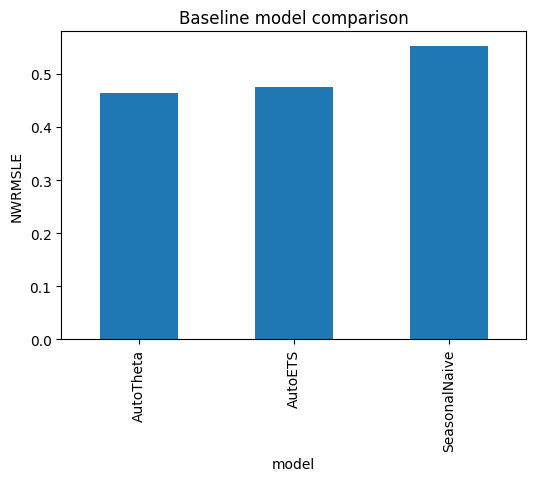

In [40]:
import matplotlib.pyplot as plt

results.sort_values("NWRMSLE").plot(
    x="model",
    y="NWRMSLE",
    kind="bar",
    legend=False,
    figsize=(6,4)
)

plt.title("Baseline model comparison")
plt.ylabel("NWRMSLE")
plt.show()


In [41]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from catboost import CatBoostRegressor
import lightgbm as lgb

# -------------------------------
# 1. Разделение train / validation
# -------------------------------

split_date = pd.Timestamp("2017-08-01")

feature_cols = [
    # lags
    "lag_1","lag_2","lag_3","lag_7","lag_14","lag_21","lag_28",

    # rolling
    "rolling_mean_7","rolling_mean_28",
    "rolling_min_7","rolling_min_28",


    # calendar
    "dayofweek","day","month","year","is_weekend","weekofyear",
    "dow_sin","dow_cos","month_sin","month_cos",

    # promo
    "onpromotion",

    # external
    "transactions_log1p",
    "oil_log1p",
    "holiday_count",
    "is_holiday",

    # ids
    "store_nbr",
    "item_nbr",
]

# убираем строки где лаги не посчитались
full_ml = full.dropna(subset=["lag_28"]).copy()

train_ml = full_ml[
    (full_ml["is_test"] == 0) &
    (full_ml["date"] < split_date)
].copy()

valid_ml = full_ml[
    (full_ml["is_test"] == 0) &
    (full_ml["date"] >= split_date)
].copy()



In [48]:
#!pip install lightgbm

In [42]:
# -------------------------------
# 2. Формируем X / y
# -------------------------------

X_train = train_ml[feature_cols]
y_train = train_ml["unit_sales"]

X_valid = valid_ml[feature_cols]
y_valid = valid_ml["unit_sales"]
w_valid = np.where(valid_ml["perishable"].fillna(0).values == 1, 1.25, 1.0)

print("Train size:", X_train.shape)
print("Valid size:", X_valid.shape)

# -------------------------------
# 3. CatBoost
# -------------------------------

cat_features = [
    feature_cols.index("store_nbr"),
    feature_cols.index("item_nbr"),
]

cat_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=200
)

cat_model.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    cat_features=cat_features,
    early_stopping_rounds=100
)

pred_cat = cat_model.predict(X_valid)
pred_cat = np.clip(pred_cat, 0, None)

nwrmsle_cat = nwrmsle(y_valid, pred_cat, w_valid)

print("CatBoost NWRMSLE:", nwrmsle_cat)

# -------------------------------
# 4. LightGBM
# -------------------------------

lgb_model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=-1,
    num_leaves=128,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="rmse",
    callbacks=[lgb.early_stopping(100)]
)

pred_lgb = lgb_model.predict(X_valid)
pred_lgb = np.clip(pred_lgb, 0, None)

nwrmsle_lgb = nwrmsle(y_valid, pred_lgb, w_valid)

print("LightGBM NWRMSLE:", nwrmsle_lgb)

# -------------------------------
# 5. Сравнение моделей
# -------------------------------

results_ml = pd.DataFrame({
    "model": [
        "SeasonalNaive",
        "AutoTheta",
        "AutoETS",
        "CatBoost",
        "LightGBM"
    ],
    "NWRMSLE": [
        snaive_score,
        theta_score,
        ets_score,
        nwrmsle_cat,
        nwrmsle_lgb
    ]
})

print(results_ml)

# -------------------------------
# 6. График сравнения


Train size: (6972444, 28)
Valid size: (1517608, 28)
0:	learn: 25.3769665	test: 21.8838001	best: 21.8838001 (0)	total: 698ms	remaining: 23m 15s
200:	learn: 16.5233434	test: 15.1259636	best: 15.1247677 (199)	total: 1m 44s	remaining: 15m 37s
400:	learn: 15.2306755	test: 15.0384396	best: 15.0355924 (393)	total: 3m 24s	remaining: 13m 34s
600:	learn: 14.4870211	test: 14.9896450	best: 14.9887681 (599)	total: 5m 8s	remaining: 11m 57s
800:	learn: 13.9667355	test: 14.9644294	best: 14.9644294 (800)	total: 6m 56s	remaining: 10m 22s
1000:	learn: 13.5300137	test: 14.9679505	best: 14.9501602 (908)	total: 8m 40s	remaining: 8m 39s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 14.95016018
bestIteration = 908

Shrink model to first 909 iterations.
CatBoost NWRMSLE: 0.5272353791142909
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.070442 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set 

Number of features: 45
['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'rolling_mean_7', 'rolling_mean_28', 'rolling_min_7', 'rolling_min_28', 'dayofweek', 'day', 'month', 'year', 'dayofyear', 'weekofyear', 'is_weekend', 'is_month_start', 'is_month_end', 'time_idx', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'onpromotion', 'is_holiday', 'holiday_count', 'transactions', 'transactions_log1p', 'oil_price', 'oil_log1p', 'promo_last_7', 'promo_last_28', 'diff_1_7', 'diff_7_14', 'store_nbr', 'item_nbr', 'city', 'state', 'type', 'cluster', 'family', 'class', 'perishable']

Train rows: (6972444, 49)
Valid rows: (1517608, 49)
Train dates: 2017-05-16 00:00:00 -> 2017-07-31 00:00:00
Valid dates: 2017-08-01 00:00:00 -> 2017-08-15 00:00:00

Categorical features for CatBoost:
['store_nbr', 'item_nbr', 'city', 'state', 'type', 'cluster', 'family', 'class', 'perishable']

NaN check:
X_train NaN: 0
X_valid NaN: 0
0:	learn: 0.8620764	test: 0.8478572	best: 0.8478572 (0)	total: 1.2

,model,NWRMSLE
0,AutoTheta,0.464694
1,AutoETS,0.475181
2,CatBoost,0.481303
3,LightGBM,0.484949
4,SeasonalNaive,0.552427


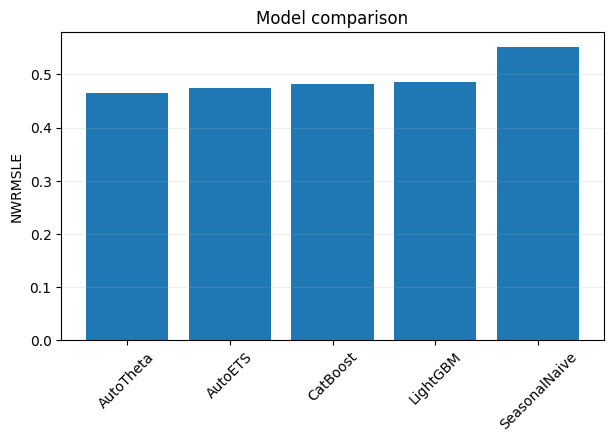


Top-20 CatBoost features:


,feature,importance
7,rolling_mean_7,24.348427
8,rolling_mean_28,24.293263
25,onpromotion,5.738715
0,lag_1,4.775134
11,dayofweek,4.667190
37,item_nbr,3.059880
21,dow_sin,2.728141
33,promo_last_28,2.575864
9,rolling_min_7,2.428737
4,lag_14,2.244028


,date,store_nbr,item_nbr,y_true,y_pred
86,2017-08-05,1,99197,1.0,1.889166
87,2017-08-07,1,99197,2.0,1.920048
88,2017-08-09,1,99197,2.0,1.929762
200,2017-08-01,1,103520,3.0,2.036818
201,2017-08-02,1,103520,1.0,2.195165


,date,store_nbr,item_nbr,y_true,y_pred
86,2017-08-05,1,99197,1.0,2.070813
87,2017-08-07,1,99197,2.0,2.047635
88,2017-08-09,1,99197,2.0,1.962717
200,2017-08-01,1,103520,3.0,1.811226
201,2017-08-02,1,103520,1.0,1.941431


In [46]:
# =========================================================
# FULL ML BLOCK: TRAIN/VALID SPLIT + CATBOOST + LIGHTGBM
# С ЛОГ-ТРАНСФОРМАЦИЕЙ TARGET
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor
import lightgbm as lgb

# ---------------------------------------------------------
# 1. Дата split
# ---------------------------------------------------------
split_date = pd.Timestamp("2017-08-01")

# ---------------------------------------------------------
# 2. Список признаков
# ВАЖНО:
# оставляем только те признаки, которые реально есть в full
# ---------------------------------------------------------
candidate_feature_cols = [
    # lags
    "lag_1","lag_2","lag_3","lag_7","lag_14","lag_21","lag_28",

    # rolling
    "rolling_mean_7","rolling_mean_28",
    "rolling_min_7","rolling_min_28",

    # calendar
    "dayofweek", "day", "month", "year", "dayofyear", "weekofyear",
    "is_weekend", "is_month_start", "is_month_end", "time_idx",
    "dow_sin", "dow_cos", "month_sin", "month_cos",

    # promo / holidays
    "onpromotion", "is_holiday", "holiday_count",

    # external
    "transactions", "transactions_log1p",
    "oil_price", "oil_log1p",

    # promo history / diff
    "promo_last_7", "promo_last_14", "promo_last_28",
    "diff_1_7", "diff_7_14",

    # ids / static
    "store_nbr", "item_nbr",
    "city", "state", "type", "cluster",
    "family", "class", "perishable",
]

feature_cols = [c for c in candidate_feature_cols if c in full.columns]

print("Number of features:", len(feature_cols))
print(feature_cols)

# ---------------------------------------------------------
# 3. Оставляем только строки train, где лаги/роллинги посчитались
# ---------------------------------------------------------
required_history_cols = [c for c in [
    "lag_1", "lag_7", "lag_14", "lag_28",
    "rolling_mean_7", "rolling_mean_14", "rolling_mean_28"
] if c in full.columns]

full_ml = full.copy()
full_ml = full_ml.dropna(subset=required_history_cols).copy()

# ---------------------------------------------------------
# 4. Time-based split
# ---------------------------------------------------------
train_ml = full_ml[
    (full_ml["is_test"] == 0) &
    (full_ml["date"] < split_date)
].copy()

valid_ml = full_ml[
    (full_ml["is_test"] == 0) &
    (full_ml["date"] >= split_date)
].copy()

print("\nTrain rows:", train_ml.shape)
print("Valid rows:", valid_ml.shape)
print("Train dates:", train_ml["date"].min(), "->", train_ml["date"].max())
print("Valid dates:", valid_ml["date"].min(), "->", valid_ml["date"].max())

# ---------------------------------------------------------
# 5. Заполнение пропусков
# CatBoost и LightGBM не любят произвольные object/NaN без контроля
# ---------------------------------------------------------
X_train = train_ml[feature_cols].copy()
X_valid = valid_ml[feature_cols].copy()

# target в лог-пространстве
y_train_log = np.log1p(train_ml["unit_sales"].values)
y_valid_raw = valid_ml["unit_sales"].values

# категориальные признаки
cat_feature_names = [c for c in [
    "store_nbr", "item_nbr",
    "city", "state", "type", "cluster",
    "family", "class", "perishable"
] if c in feature_cols]

num_feature_names = [c for c in feature_cols if c not in cat_feature_names]

# числовые пропуски
for col in num_feature_names:
    if X_train[col].isna().any():
        X_train[col] = X_train[col].fillna(0)
    if X_valid[col].isna().any():
        X_valid[col] = X_valid[col].fillna(0)

# категориальные пропуски
for col in cat_feature_names:
    if str(X_train[col].dtype) in ["object", "string", "category"]:
        X_train[col] = X_train[col].astype("object").fillna("unknown")
        X_valid[col] = X_valid[col].astype("object").fillna("unknown")
    else:
        X_train[col] = X_train[col].fillna(-1)
        X_valid[col] = X_valid[col].fillna(-1)

# индексы категориальных фич для CatBoost
cat_features_idx = [X_train.columns.get_loc(c) for c in cat_feature_names]

print("\nCategorical features for CatBoost:")
print(cat_feature_names)

print("\nNaN check:")
print("X_train NaN:", int(X_train.isna().sum().sum()))
print("X_valid NaN:", int(X_valid.isna().sum().sum()))

# ---------------------------------------------------------
# 6. Метрика NWRMSLE + веса validation
# ---------------------------------------------------------
w_valid = np.where(valid_ml["perishable"].fillna(0).values == 1, 1.25, 1.0)

# ---------------------------------------------------------
# 7. CatBoost
# ---------------------------------------------------------
cat_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",   # RMSE в log-space
    eval_metric="RMSE",
    random_seed=42,
    verbose=200
)

cat_model.fit(
    X_train,
    y_train_log,
    eval_set=(X_valid, np.log1p(y_valid_raw)),
    cat_features=cat_features_idx,
    early_stopping_rounds=100,
)

pred_cat_log = cat_model.predict(X_valid)
pred_cat = np.expm1(pred_cat_log)
pred_cat = np.clip(pred_cat, 0, None)

nwrmsle_cat = nwrmsle(y_valid_raw, pred_cat, w_valid)
print("\nCatBoost NWRMSLE:", nwrmsle_cat)

# ---------------------------------------------------------
# 8. LightGBM
# В LightGBM категориальные object лучше перевести в category/int
# ---------------------------------------------------------
X_train_lgb = X_train.copy()
X_valid_lgb = X_valid.copy()

for col in cat_feature_names:
    if str(X_train_lgb[col].dtype) in ["object", "string", "category"]:
        all_values = pd.concat([X_train_lgb[col], X_valid_lgb[col]], axis=0).astype("category")
        categories = all_values.cat.categories
        X_train_lgb[col] = pd.Categorical(X_train_lgb[col], categories=categories).codes
        X_valid_lgb[col] = pd.Categorical(X_valid_lgb[col], categories=categories).codes
    else:
        X_train_lgb[col] = X_train_lgb[col].astype("int32")
        X_valid_lgb[col] = X_valid_lgb[col].astype("int32")

lgb_model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=-1,
    num_leaves=128,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

lgb_model.fit(
    X_train_lgb,
    y_train_log,
    eval_set=[(X_valid_lgb, np.log1p(y_valid_raw))],
    eval_metric="rmse",
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)],
)

pred_lgb_log = lgb_model.predict(X_valid_lgb)
pred_lgb = np.expm1(pred_lgb_log)
pred_lgb = np.clip(pred_lgb, 0, None)

nwrmsle_lgb = nwrmsle(y_valid_raw, pred_lgb, w_valid)
print("LightGBM NWRMSLE:", nwrmsle_lgb)

# ---------------------------------------------------------
# 9. Сравнение с baseline
# Предполагается, что уже есть:
# snaive_score, theta_score, ets_score
# ---------------------------------------------------------
results_ml = pd.DataFrame({
    "model": [
        "SeasonalNaive",
        "AutoTheta",
        "AutoETS",
        "CatBoost",
        "LightGBM",
    ],
    "NWRMSLE": [
        snaive_score,
        theta_score,
        ets_score,
        nwrmsle_cat,
        nwrmsle_lgb,
    ]
}).sort_values("NWRMSLE").reset_index(drop=True)

print("\nModel comparison:")
display(results_ml)

# ---------------------------------------------------------
# 10. График сравнения
# ---------------------------------------------------------
plt.figure(figsize=(7, 4))
plt.bar(results_ml["model"], results_ml["NWRMSLE"])
plt.title("Model comparison")
plt.ylabel("NWRMSLE")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)
plt.show()

# ---------------------------------------------------------
# 11. Feature importance
# ---------------------------------------------------------
cat_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": cat_model.get_feature_importance()
}).sort_values("importance", ascending=False)

print("\nTop-20 CatBoost features:")
display(cat_importance.head(20))

# ---------------------------------------------------------
# 12. Сохраняем предсказания validation для дальнейшего анализа / plotting
# ---------------------------------------------------------
valid_pred_cat_df = valid_ml[["date", "store_nbr", "item_nbr", "unit_sales"]].copy()
valid_pred_cat_df = valid_pred_cat_df.rename(columns={"unit_sales": "y_true"})
valid_pred_cat_df["y_pred"] = pred_cat

valid_pred_lgb_df = valid_ml[["date", "store_nbr", "item_nbr", "unit_sales"]].copy()
valid_pred_lgb_df = valid_pred_lgb_df.rename(columns={"unit_sales": "y_true"})
valid_pred_lgb_df["y_pred"] = pred_lgb

display(valid_pred_cat_df.head())
display(valid_pred_lgb_df.head())


In [47]:

def build_preds_for_plotly_item_level(
    train_hist_df,
    pred_df,
    context_points=60,
    store_col="store_nbr",
    item_col="item_nbr",
    date_col="date",
    hist_value_col="unit_sales",
    true_col="y_true",
    pred_col="y_pred",
    fill_missing_future=0.0,
):
    """
    Готовит preds для plot_results_plotly_universal.

    Один объект = один временной ряд (store_nbr, item_nbr).
    В поле family_id кладем item_id.

    """

    train_hist_df = train_hist_df.copy()
    pred_df = pred_df.copy()

    train_hist_df[date_col] = pd.to_datetime(train_hist_df[date_col])
    pred_df[date_col] = pd.to_datetime(pred_df[date_col])

    # ---------------------------------------------------------
    # 1. Кодирование item_nbr -> item_id
    # ---------------------------------------------------------
    all_items = pd.concat(
        [train_hist_df[item_col], pred_df[item_col]],
        axis=0
    ).dropna().unique().tolist()
    all_items = sorted(all_items)
    item_to_id = {item: i for i, item in enumerate(all_items)}

    train_hist_df["item_id"] = train_hist_df[item_col].map(item_to_id).astype(int)
    pred_df["item_id"] = pred_df[item_col].map(item_to_id).astype(int)

    # ---------------------------------------------------------
    # 2. Общий горизонт valid-дат
    # ---------------------------------------------------------
    horizon_dates = np.array(sorted(pred_df[date_col].dropna().unique()))
    H = len(horizon_dates)

    # ---------------------------------------------------------
    # 3. История по каждому (store, item)
    # ---------------------------------------------------------
    hist_map = {}
    for (sid, iid), g in train_hist_df.groupby([store_col, "item_id"], observed=False):
        g = g.sort_values(date_col)
        hist = g[hist_value_col].tail(context_points).to_numpy(dtype=float)

        if len(hist) < context_points:
            hist = np.pad(
                hist,
                (context_points - len(hist), 0),
                constant_values=0.0
            )

        hist_map[(sid, iid)] = hist

    y_true_list = []
    y_pred_list = []
    x_y_list = []
    store_id_list = []
    family_id_list = []

    for (sid, iid), g in pred_df.groupby([store_col, "item_id"], observed=False):
        g = g.sort_values(date_col)

        # если по одной дате несколько строк, агрегируем
        g_agg = (
            g.groupby(date_col, as_index=False)[[true_col, pred_col]]
            .mean()
            .sort_values(date_col)
        )

        g_agg = g_agg.set_index(date_col).reindex(horizon_dates)

        y_true_arr = g_agg[true_col].fillna(fill_missing_future).to_numpy(dtype=float)
        y_pred_arr = g_agg[pred_col].fillna(fill_missing_future).to_numpy(dtype=float)

        # теперь длина у всех одинаковая = H
        hist = hist_map.get((sid, iid))
        if hist is None:
            hist = np.zeros(context_points, dtype=float)

        y_true_list.append(y_true_arr)
        y_pred_list.append(y_pred_arr)
        x_y_list.append(hist)
        store_id_list.append(int(sid))
        family_id_list.append(int(iid))

    preds = {
        "y_true": np.stack(y_true_list),
        "y_pred": np.stack(y_pred_list),
        "x_y": np.stack(x_y_list),
        "store_id": np.array(store_id_list, dtype=int),
        "family_id": np.array(family_id_list, dtype=int),
    }

    return preds, item_to_id, horizon_dates

In [48]:
train_hist_item = train_ml[["date", "store_nbr", "item_nbr", "unit_sales"]].copy()

preds_cat, item_to_id, horizon_dates = build_preds_for_plotly_item_level(
    train_hist_df=train_hist_item,
    pred_df=valid_pred_cat_df,
    context_points=60,
    store_col="store_nbr",
    item_col="item_nbr",
    date_col="date",
    hist_value_col="unit_sales",
    true_col="y_true",
    pred_col="y_pred",
    fill_missing_future=0.0,
)

preds_lgb, _, _ = build_preds_for_plotly_item_level(
    train_hist_df=train_hist_item,
    pred_df=valid_pred_lgb_df,
    context_points=60,
    store_col="store_nbr",
    item_col="item_nbr",
    date_col="date",
    hist_value_col="unit_sales",
    true_col="y_true",
    pred_col="y_pred",
    fill_missing_future=0.0,
)

print("CatBoost forecast plots")
figs_cat = plot_results_plotly_universal(
    preds=preds_cat,
    series_data=None,
    n_series=5,
    context_points=60,
    seed=42,
    point_mode="median",
    quantile_index=1,
    normalized=False,
)

print("LightGBM forecast plots")
figs_lgb = plot_results_plotly_universal(
    preds=preds_lgb,
    series_data=None,
    n_series=5,
    context_points=60,
    seed=42,
    point_mode="median",
    quantile_index=1,
    normalized=False,
)

CatBoost forecast plots


LightGBM forecast plots
